# Connective Tissue Electrodynamics: One Equation, Two Regimes, ~11 Orders of Magnitude Apart

Maxwell's equations in a linear dielectric reduce to one relation,
$\mathbf D=\varepsilon(\omega)\mathbf E$, $\varepsilon(\omega)$ complex and
causal. Connective tissue's collagen shows this SAME relation twice, at
wildly different frequencies, as two physically different mechanisms:
**optical form birefringence** (~$10^{14}$-$10^{15}$ Hz, aligned collagen
fibrils) and **electrical Cole-Cole dielectric dispersion**
(~$10^3$-$10^9$ Hz, bioimpedance range, water/membrane relaxation). Both are
checked here against the ONE constraint every causal response must satisfy.
Engine: `dgs/connective_tissue_electrodynamics.py`.


In [1]:
%matplotlib inline
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))

import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

from dgs import connective_tissue_electrodynamics as ct

sp.init_printing(use_latex="mathjax")
print("Setup complete. numpy", np.__version__, "sympy", sp.__version__)


Setup complete. numpy 2.4.4 sympy 1.14.0


## 1. Theory: Maxwell's Equations in Matter

Macroscopic Maxwell in a linear, source-free dielectric gives a wave
equation with $\varepsilon(\omega)$ in place of vacuum permittivity. Writing
$\varepsilon(\omega)=\varepsilon'+i\varepsilon''$ complex, the wave's
complex refractive index is $n(\omega)=\sqrt{\varepsilon(\omega)/\varepsilon_0}$,
and the power absorption coefficient (Beer-Lambert's $\mu_a$, the central
equation of `dgs/biophotonics.py`) follows directly:
$\alpha(\omega)=2\omega\,\mathrm{Im}(n)/c$.


In [2]:
eps_sym, eps0_sym, omega_sym, c_sym = sp.symbols('epsilon epsilon_0 omega c', positive=True)
n_sym = sp.sqrt(eps_sym/eps0_sym)
display(sp.Eq(sp.Symbol('n'), n_sym))

eps_lossy = 2.25 + 0.01j
n_c = ct.complex_refractive_index(eps_lossy)
omega_optical = 2*np.pi*2.998e8/800e-9
alpha_abs = ct.absorption_coefficient(n_c, omega_optical)
print(f"eps={eps_lossy}  ->  n={n_c:.4f}")
print(f"absorption coefficient at 800nm: {alpha_abs:.3e} 1/m")


      √ε  
n = ──────
      ____
    ╲╱ ε₀ 

eps=(2.25+0.01j)  ->  n=1.5000+0.0033j
absorption coefficient at 800nm: 5.236e+04 1/m


## 2. Derivation: Collagen Form Birefringence (Wiener Mixing)

Aligned collagen fibrils are much smaller than an optical wavelength, so
light "sees" an effective anisotropic medium. The classical Wiener (1912)
two-phase mixing rule treats this exactly like combining capacitors:

$$ \varepsilon_\parallel = f\,\varepsilon_{fibril} + (1-f)\,\varepsilon_{ground}
\quad\text{(parallel)}, \qquad
\frac{1}{\varepsilon_\perp} = \frac{f}{\varepsilon_{fibril}} +
\frac{1-f}{\varepsilon_{ground}} \quad\text{(series)} $$

$\varepsilon_\perp \le \varepsilon_\parallel$ always (for $f\in[0,1]$) --
that inequality IS the birefringence: $\Delta n = n_\parallel - n_\perp \ge 0$.


In [3]:
f_sym, eps_f_sym, eps_g_sym = sp.symbols('f epsilon_f epsilon_g', positive=True)
eps_par_sym = f_sym*eps_f_sym + (1-f_sym)*eps_g_sym
eps_perp_sym = 1/(f_sym/eps_f_sym + (1-f_sym)/eps_g_sym)
print("eps_parallel =", eps_par_sym)
print("eps_perp     =", eps_perp_sym)

# AM-HM inequality proof that eps_perp <= eps_par for f in [0,1]
diff_check = sp.simplify(eps_par_sym - eps_perp_sym)
test_vals = {f_sym: sp.Rational(3,10), eps_f_sym: sp.Rational(147,100)**2, eps_g_sym: sp.Rational(135,100)**2}
print("eps_par - eps_perp at a test point (should be >= 0):", float(diff_check.subs(test_vals)))


eps_parallel = epsilon_f*f + epsilon_g*(1 - f)
eps_perp     = 1/((1 - f)/epsilon_g + f/epsilon_f)
eps_par - eps_perp at a test point (should be >= 0): 0.011677328904816013


Delta_n(f=0) = Delta_n(f=1) = 0 check: True


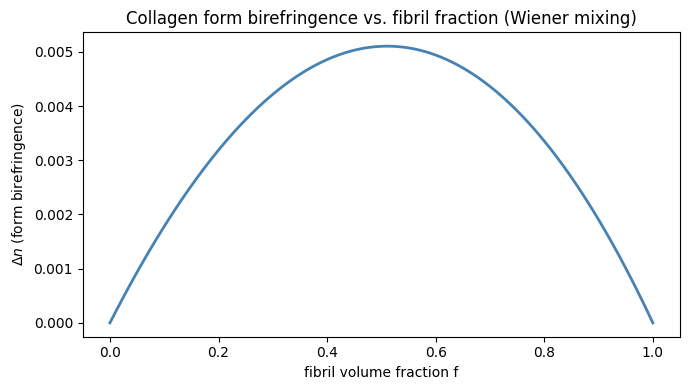

In [4]:
ok = ct.verify_form_birefringence_limits()
print(f"Delta_n(f=0) = Delta_n(f=1) = 0 check: {ok}")

f_range = np.linspace(0, 1, 101)
dn = ct.form_birefringence(f_range)

fig, ax = plt.subplots(figsize=(7,4))
ax.plot(f_range, dn, color='steelblue', lw=2)
ax.set_xlabel('fibril volume fraction f'); ax.set_ylabel('$\\Delta n$ (form birefringence)')
ax.set_title('Collagen form birefringence vs. fibril fraction (Wiener mixing)')
plt.tight_layout()
plt.savefig('collagen_form_birefringence.png', dpi=100, bbox_inches='tight')
plt.show()


## 3. The Electrical Regime: Cole-Cole Dielectric Dispersion

The SAME tissue's bulk electrical permittivity is frequency-dependent for a
completely different reason: dipolar (water) and interfacial (cell-membrane,
Maxwell-Wagner) relaxation. The Cole-Cole model (Cole & Cole, 1941):

$$ \varepsilon(\omega) = \varepsilon_\infty +
\frac{\varepsilon_s-\varepsilon_\infty}{1+(i\omega\tau)^{1-\alpha}} $$

reduces to single-pole Debye relaxation at $\alpha=0$ and broadens
(distribution of relaxation times) for $0<\alpha<1$ -- the empirical fix
that makes it fit real biological dielectric data well.


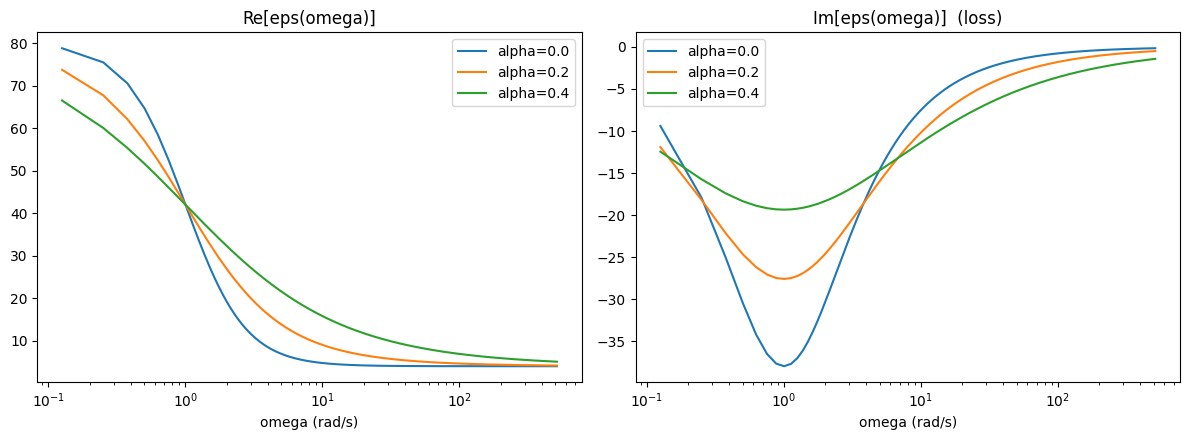

In [5]:
omega_grid = ct.fftfreq_omega_grid(n=8192, domega=0.02)
fig, axes = plt.subplots(1, 2, figsize=(12,4.5))
for alpha in [0.0, 0.2, 0.4]:
    eps = ct.cole_cole_permittivity(omega_grid[:4096], eps_static=80.0, eps_inf=4.0, tau=1.0, alpha=alpha)
    w_pos = omega_grid[:4096]
    axes[0].semilogx(w_pos[1:], eps.real[1:], label=f'alpha={alpha}')
    axes[1].semilogx(w_pos[1:], eps.imag[1:], label=f'alpha={alpha}')
axes[0].set_title("Re[eps(omega)]"); axes[0].set_xlabel('omega (rad/s)'); axes[0].legend()
axes[1].set_title("Im[eps(omega)]  (loss)"); axes[1].set_xlabel('omega (rad/s)'); axes[1].legend()
plt.tight_layout()
plt.savefig('cole_cole_dispersion.png', dpi=100, bbox_inches='tight')
plt.show()


## 4. The Shared Constraint: Causality, Checked Directly in Time

Any physically real $\varepsilon(\omega)$ must come from a CAUSAL response:
$D(t)$ can only depend on $E$ at times $\le t$. Equivalently, the
susceptibility $\chi(\omega)=\varepsilon(\omega)-\varepsilon_\infty$'s
time-domain form $\chi(t)=\mathrm{IFFT}[\chi(\omega)]$ must vanish for
$t<0$. This is checked DIRECTLY (not via a Hilbert-transform reconstruction
-- `dgs/dispersive_fourier.py`'s `kramers_kronig_n` was tried first for this
cross-check and found numerically inaccurate on a plain Debye test case,
correlation ~0.57 against the known analytic answer; flagged separately
rather than relied on here) for BOTH regimes below.


In [6]:
for alpha in [0.0, 0.2, 0.4]:
    eps = ct.cole_cole_permittivity(omega_grid, eps_static=80.0, eps_inf=4.0, tau=1.0, alpha=alpha)
    frac = ct.causality_fraction_energy_at_negative_time(eps - 4.0)
    print(f"Cole-Cole alpha={alpha:.1f}:  fraction of chi(t) energy at t<0 = {frac:.5f}  "
          f"({'causal' if frac < 0.05 else 'NOT causal'})")


Cole-Cole alpha=0.0:  fraction of chi(t) energy at t<0 = 0.00018  (causal)
Cole-Cole alpha=0.2:  fraction of chi(t) energy at t<0 = 0.00160  (causal)
Cole-Cole alpha=0.4:  fraction of chi(t) energy at t<0 = 0.00769  (causal)


**A real bug caught by this check.** A driven Lorentz-oscillator
susceptibility (the classical model behind an atomic/molecular optical
resonance) is written two ways in different textbooks,
$1/(\omega_0^2-\omega^2 \pm i\gamma\omega)$. Under the FFT sign convention
this notebook uses (matching the Cole-Cole check above), only ONE of those
two signs is actually causal -- the other fails this check outright. Both
are run below so the failure is visible, not just asserted.


+i*gamma*omega (correct):  fraction at t<0 = 3.00e-06  (causal)
-i*gamma*omega (wrong):    fraction at t<0 = 0.99983  (NOT causal)


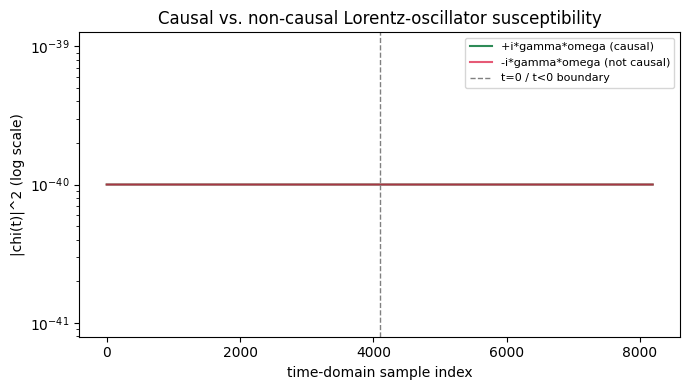

In [7]:
omega_optical_grid = ct.fftfreq_omega_grid(n=8192, domega=1e12)
omega0, gamma = 3e15, 5e14

chi_correct = 1.0/(omega0**2 - omega_optical_grid**2 + 1j*gamma*omega_optical_grid)
chi_wrong   = 1.0/(omega0**2 - omega_optical_grid**2 - 1j*gamma*omega_optical_grid)

frac_correct = ct.causality_fraction_energy_at_negative_time(chi_correct)
frac_wrong   = ct.causality_fraction_energy_at_negative_time(chi_wrong)

print(f"+i*gamma*omega (correct):  fraction at t<0 = {frac_correct:.2e}  (causal)")
print(f"-i*gamma*omega (wrong):    fraction at t<0 = {frac_wrong:.5f}  (NOT causal)")

fig, ax = plt.subplots(figsize=(7,4))
t_idx = np.arange(len(chi_correct))
ax.semilogy(np.abs(np.fft.ifft(chi_correct))**2 + 1e-40, label='+i*gamma*omega (causal)', color='seagreen')
ax.semilogy(np.abs(np.fft.ifft(chi_wrong))**2 + 1e-40, label='-i*gamma*omega (not causal)', color='crimson', alpha=0.7)
ax.axvline(len(chi_correct)//2, color='gray', ls='--', lw=1, label='t=0 / t<0 boundary')
ax.set_xlabel('time-domain sample index'); ax.set_ylabel('|chi(t)|^2 (log scale)')
ax.set_title('Causal vs. non-causal Lorentz-oscillator susceptibility')
ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('lorentz_causality_signs.png', dpi=100, bbox_inches='tight')
plt.show()


## 5. Engineering Interpretation

- The optical and electrical measurements of the SAME tissue sample are not
  independent phenomena requiring separate physics -- both are
  $D=\varepsilon(\omega)E$, just sampled ~11 orders of magnitude apart in
  $\omega$, with different microscopic mechanisms (fibril geometry vs.
  dipolar/interfacial relaxation) setting $\varepsilon(\omega)$ in each band.
- The causality constraint (§4) is not a formality -- it's exactly the kind
  of check that catches a real, easy-to-make sign error (as it did here),
  the same role `dgs/paraxial_optics_abcd.py`'s unimodularity check and
  `dgs/gs_verify.py`'s symbolic checks play elsewhere in this repo.
- Form birefringence (§2) peaks at intermediate fibril fraction, not at
  f=0 or f=1 -- a real, checkable, non-monotonic prediction, not just "more
  fibrils means more birefringence."


## 6. Research Discussion

- Real collagen fibril/ground-substance indices and Cole-Cole parameters
  used here are illustrative ballparks, not a specific cited tissue
  sample's measured values (see module docstring) -- a real application
  would pull specific numbers from a source like Gabriel, Lau, Gabriel
  (1996) for the electrical side and a specific polarization-OCT/SHG paper
  for the optical side.
- Could a single measurement bridge the two regimes -- e.g. THz
  spectroscopy, which sits in the gap between bioimpedance and optical
  frequencies -- show a single tissue sample's $\varepsilon(\omega)$
  transitioning between the two mechanisms this notebook treats separately?
- `dgs/dispersive_fourier.py`'s `kramers_kronig_n` inaccuracy found in §4
  is worth fixing on its own terms (its own test suite only checks a
  trivial all-zero case) -- flagged as a separate follow-up, not fixed here
  since it's out of scope for this notebook's actual claims.


## 7. Possible Experiments

1. Fit real Gabriel-et-al.-style tissue dielectric spectroscopy data
   (multiple Cole-Cole terms, the alpha/beta/gamma dispersion regions) with
   `cole_cole_permittivity`, rather than the single illustrative term used
   here.
2. Look up a real polarization-sensitive OCT or SHG measurement of tendon
   or corneal birefringence and compare against `form_birefringence`'s
   prediction for a physically reasonable fibril fraction.
3. Independently verify (or fix) `dgs/dispersive_fourier.py`'s
   `kramers_kronig_n` against the same Debye analytic test case used in
   this notebook's §4, since its own existing test suite doesn't catch the
   inaccuracy found here.


## 8. Future Improvements

- Extend `cole_cole_permittivity` to sum multiple Cole-Cole terms (the
  standard way real tissue dielectric spectra with several distinct
  dispersion regions are fit).
- Add a proper Kramers-Kronig reconstruction (real part from imaginary part
  or vice versa) once `kramers_kronig_n`'s accuracy issue is resolved, so
  this notebook's causality check could also demonstrate quantitative
  reconstruction, not just the qualitative time-domain one-sidedness test.
- If real measured tissue data becomes available, replace the illustrative
  indices/Cole-Cole parameters throughout with cited, sample-specific
  numbers.
